<a href="https://colab.research.google.com/github/Hhasan04/MLHomeWorks/blob/MLProject/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install and Import Libraries
# Install required packages
!pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report, confusion_matrix
from scipy.stats import multivariate_normal

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Load Dataset
# Upload your CSV file in Colab or specify the path
from google.colab import files
#uploaded = files.upload()

# Get the uploaded filename
#filename = list(uploaded.keys())[0]
df = pd.read_csv("/content/transactions.csv")

print(f"Dataset shape: {df.shape}")
print("\nFraud distribution:")
print(df['is_fraud'].value_counts())
print(f"Fraud percentage: {df['is_fraud'].mean()*100:.2f}%")

Dataset shape: (299695, 17)

Fraud distribution:
is_fraud
0    293083
1      6612
Name: count, dtype: int64
Fraud percentage: 2.21%


In [ ]:
# Cell 4: Feature Engineering - Time Features
# Convert transaction_time to datetime and extract features
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# Extract time-based features
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['transaction_time'].dt.day
df['month'] = df['transaction_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # Saturday or Sunday

# Create cyclical features for hour (to capture circular nature of time)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Create cyclical features for day of week
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("Time features created:")
print(df[['transaction_time', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos']].head())
print(f"Dataset shape: {df.shape}")


Time features created:
           transaction_time  hour  day_of_week  is_weekend  hour_sin  \
0 2024-01-06 04:09:39+00:00     4            5           1  0.866025   
1 2024-01-09 20:13:47+00:00    20            1           0 -0.866025   
2 2024-01-12 06:20:11+00:00     6            4           0  1.000000   
3 2024-01-15 17:00:04+00:00    17            0           0 -0.965926   
4 2024-01-17 01:27:31+00:00     1            2           0  0.258819   

       hour_cos  
0  5.000000e-01  
1  5.000000e-01  
2  6.123234e-17  
3 -2.588190e-01  
4  9.659258e-01  
Dataset shape: (299695, 26)


In [ ]:
# Cell 5: Preprocessing - Drop Identifiers and Original Time Column
# Drop columns not needed for modeling
columns_to_drop = ['transaction_id', 'user_id', 'transaction_time']
df_processed = df.drop(columns=columns_to_drop)

print(f"Columns after dropping identifiers: {df_processed.shape[1]}")
print(f"Remaining columns: {list(df_processed.columns)}")

Columns after dropping identifiers: 23
Remaining columns: ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_fraud', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


In [ ]:
# Cell 6: Separate Labels from Features
# Separate the target variable (only for evaluation, not training)
y_true = df_processed['is_fraud'].values
X = df_processed.drop(columns=['is_fraud'])

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_true.shape}")
print(f"Number of fraud cases: {y_true.sum()}")
print(f"Number of normal cases: {(y_true == 0).sum()}")

Features shape: (299695, 22)
Labels shape: (299695,)
Number of fraud cases: 6612
Number of normal cases: 293083


In [ ]:
# Cell 7: Identify Column Types
# Identify numeric and categorical columns
numeric_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
                'amount', 'shipping_distance_km', 'hour', 'day_of_week',
                'day_of_month', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

binary_cols = ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_weekend']

categorical_cols = ['country', 'bin_country', 'channel', 'merchant_category']

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nBinary columns ({len(binary_cols)}): {binary_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns (13): ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km', 'hour', 'day_of_week', 'day_of_month', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

Binary columns (5): ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_weekend']

Categorical columns (4): ['country', 'bin_country', 'channel', 'merchant_category']


In [ ]:
# Cell 8: Encode Categorical Variables
# Use Label Encoding for categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {X_encoded[col].nunique()} unique values")

print("\nEncoded dataset shape:", X_encoded.shape)

Encoded country: 10 unique values
Encoded bin_country: 10 unique values
Encoded channel: 2 unique values
Encoded merchant_category: 5 unique values

Encoded dataset shape: (299695, 22)


In [ ]:
# Cell 9: Scale Numeric Features
# Standardize numeric features (important for distance-based methods)
scaler = StandardScaler()

# Scale only numeric columns (not binary or already encoded categoricals)
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("Features scaled successfully!")

Features scaled successfully!


In [ ]:
# Cell 9.5: Dimensionality Reduction using PCA
from sklearn.decomposition import PCA

# اختيار عدد المكونات (ابدأ بـ 10 أو 15)
pca = PCA(n_components=10, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("PCA applied successfully!")
print(f"Original feature dimension: {X_scaled.shape[1]}")
print(f"Reduced feature dimension: {X_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")


PCA applied successfully!
Original feature dimension: 22
Reduced feature dimension: 10
Explained variance ratio: 0.8725


In [ ]:
# Cell 10: Prepare Training Data for Gaussian Model
# For Gaussian anomaly detection, use ONLY normal (non-fraud) transactions for training
# This prevents data leakage
normal_mask = (y_true == 0)
X_train_normal = X_scaled[normal_mask]
y_train_normal = y_true[normal_mask]

print(f"Total samples: {len(X_scaled)}")
print(f"Normal samples (for Gaussian training): {len(X_train_normal)}")
print(f"Fraud samples: {y_true.sum()}")
print(f"\nPercentage of data used for Gaussian training: {len(X_train_normal)/len(X_scaled)*100:.2f}%")


Total samples: 299695
Normal samples (for Gaussian training): 293083
Fraud samples: 6612

Percentage of data used for Gaussian training: 97.79%


In [ ]:
# Cell 11: Method 1 - Isolation Forest Anomaly Detection
print("=" * 60)
print("METHOD 1: ISOLATION FOREST ANOMALY DETECTION")
print("=" * 60)

isoforest = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination=0.0221,   # نسبة الاحتيال المتوقعة
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# Fit on ALL data (unsupervised)
isoforest.fit(X_scaled)

# sklearn: -1 = anomaly, 1 = normal
iso_labels = isoforest.predict(X_scaled)

# Convert to binary anomaly label
iso_anomalies = (iso_labels == -1).astype(int)

# Anomaly scores (higher = more anomalous)
iso_scores = -isoforest.score_samples(X_scaled)

print(f"Detected anomalies: {iso_anomalies.sum()}")
print(f"Percentage anomalies: {iso_anomalies.mean()*100:.2f}%")


METHOD 1: ISOLATION FOREST ANOMALY DETECTION
Detected anomalies: 6624
Percentage anomalies: 2.21%


In [ ]:
# Cell 12: Method 2 - Gaussian Anomaly Detection
print("=" * 60)
print("METHOD 2: GAUSSIAN ANOMALY DETECTION")
print("=" * 60)

# Fit Gaussian distribution on NORMAL transactions only
# Estimate mean and covariance
gaussian_mean = X_train_normal.mean(axis=0).values
gaussian_cov = EmpiricalCovariance().fit(X_train_normal).covariance_

print(f"Gaussian model trained on {len(X_train_normal)} normal transactions")
print(f"Feature dimension: {len(gaussian_mean)}")

# Compute probability density for ALL transactions
# Use multivariate normal distribution
mvn = multivariate_normal(mean=gaussian_mean, cov=gaussian_cov, allow_singular=True)
gaussian_log_likelihood = mvn.logpdf(X_scaled)

# Convert to anomaly scores (lower likelihood = higher anomaly score)
# Negative log-likelihood as anomaly score
gaussian_anomaly_scores = -gaussian_log_likelihood

print(f"\nGaussian anomaly scores computed for all {len(gaussian_anomaly_scores)} transactions")
print(f"Score range: [{gaussian_anomaly_scores.min():.2f}, {gaussian_anomaly_scores.max():.2f}]")
print(f"Mean score: {gaussian_anomaly_scores.mean():.2f}")
print(f"Std score: {gaussian_anomaly_scores.std():.2f}")


METHOD 2: GAUSSIAN ANOMALY DETECTION
Gaussian model trained on 293083 normal transactions
Feature dimension: 22

Gaussian anomaly scores computed for all 299695 transactions
Score range: [15.96, 3259.56]
Mean score: 24.68
Std score: 16.47


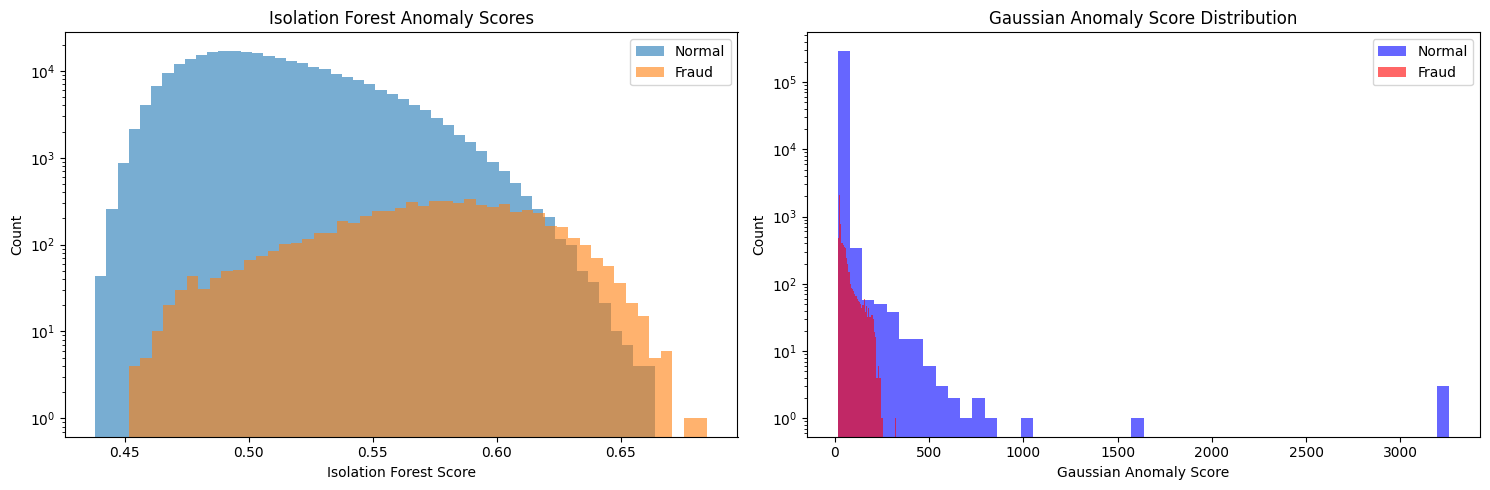

In [ ]:
# Cell 13: Visualize Anomaly Score Distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(iso_scores[y_true == 0], bins=50, alpha=0.6, label='Normal')
axes[0].hist(iso_scores[y_true == 1], bins=50, alpha=0.6, label='Fraud')
axes[0].set_xlabel('Isolation Forest Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Isolation Forest Anomaly Scores')
axes[0].legend()
axes[0].set_yscale('log')

# Gaussian scores
axes[1].hist(gaussian_anomaly_scores[y_true == 0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[1].hist(gaussian_anomaly_scores[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='red')
axes[1].set_xlabel('Gaussian Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Gaussian Anomaly Score Distribution')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 14: Compute ROC Curves
print("=" * 60)
print("ROC ANALYSIS")
print("=" * 60)

# DBSCAN ROC Curve
fpr_iso, tpr_iso, _ = roc_curve(y_true, iso_scores)
roc_auc_iso = auc(fpr_iso, tpr_iso)

# Gaussian ROC Curve
fpr_gaussian, tpr_gaussian, thresholds_gaussian = roc_curve(y_true, gaussian_anomaly_scores)
roc_auc_gaussian = auc(fpr_gaussian, tpr_gaussian)

print(f"\Isolation Forest ROC-AUC: {roc_auc_iso:.4f}")
print(f"Gaussian ROC-AUC: {roc_auc_gaussian:.4f}")

ROC ANALYSIS

DBSCAN ROC-AUC: 0.8828
Gaussian ROC-AUC: 0.8818


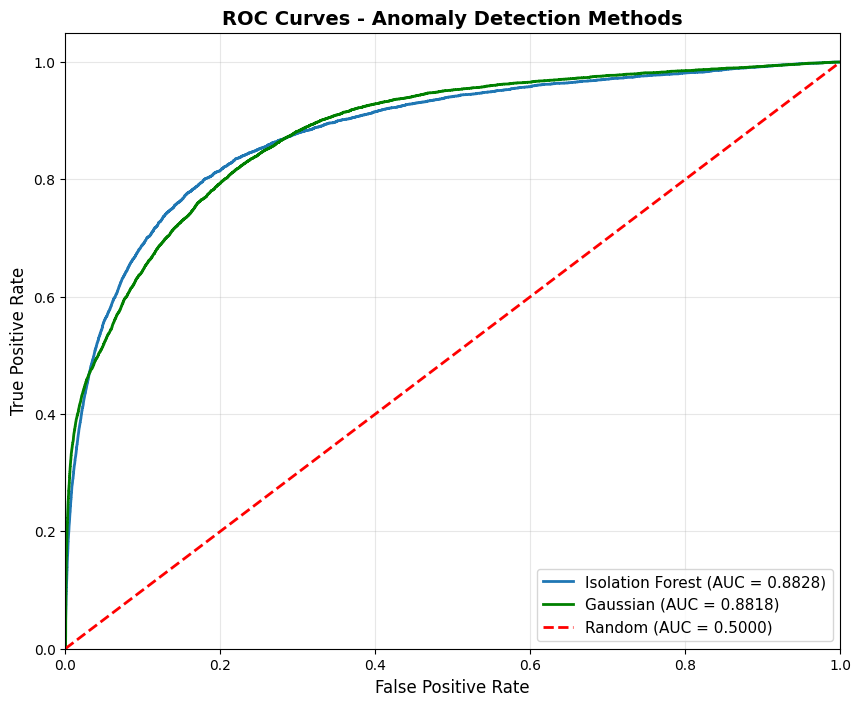

In [ ]:
# Cell 15: Plot ROC Curves
plt.figure(figsize=(10, 8))

# Plot DBSCAN ROC
plt.plot(fpr_iso, tpr_iso, lw=2,
         label=f'Isolation Forest (AUC = {roc_auc_iso:.4f})')

# Plot Gaussian ROC
plt.plot(fpr_gaussian, tpr_gaussian, color='green', lw=2,
         label=f'Gaussian (AUC = {roc_auc_gaussian:.4f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Anomaly Detection Methods', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Cell 16: Precision-Recall Analysis
print("=" * 60)
print("PRECISION-RECALL ANALYSIS")
print("=" * 60)

# DBSCAN Precision-Recall
precision_iso, recall_iso, _ = precision_recall_curve(y_true, iso_scores)
pr_auc_iso = auc(recall_iso, precision_iso)

# Gaussian Precision-Recall
precision_gaussian, recall_gaussian, _ = precision_recall_curve(y_true, gaussian_anomaly_scores)
pr_auc_gaussian = auc(recall_gaussian, precision_gaussian)

print(f"\nDBSCAN PR-AUC: {pr_auc_iso:.4f}")
print(f"Gaussian PR-AUC: {pr_auc_gaussian:.4f}")

PRECISION-RECALL ANALYSIS

DBSCAN PR-AUC: 0.2907
Gaussian PR-AUC: 0.3134


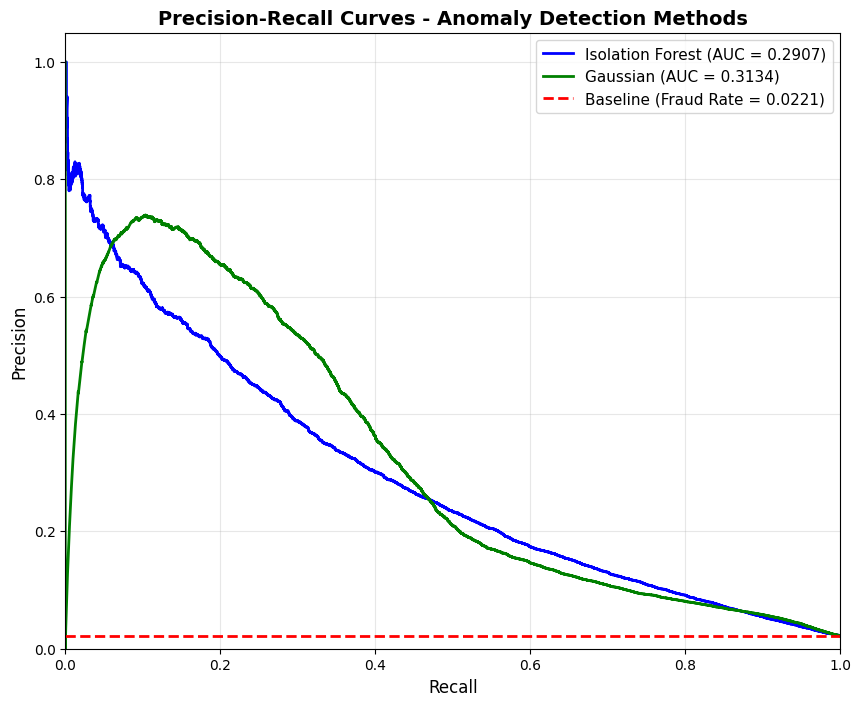

In [ ]:
# Cell 17: Plot Precision-Recall Curves
plt.figure(figsize=(10, 8))

# Plot DBSCAN PR
plt.plot(recall_iso, precision_iso, color='blue', lw=2,
         label=f'Isolation Forest (AUC = {pr_auc_iso:.4f})')

# Plot Gaussian PR
plt.plot(recall_gaussian, precision_gaussian, color='green', lw=2,
         label=f'Gaussian (AUC = {pr_auc_gaussian:.4f})')

# Baseline (fraud rate)
baseline = y_true.mean()
plt.axhline(y=baseline, color='red', linestyle='--', lw=2,
            label=f'Baseline (Fraud Rate = {baseline:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Anomaly Detection Methods', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Cell 18: Detailed Performance Metrics at Different Thresholds
# Choose thresholds for binary classification
# For Gaussian: use percentile-based threshold
gaussian_threshold_95 = np.percentile(gaussian_anomaly_scores, 95)
gaussian_threshold_98 = np.percentile(gaussian_anomaly_scores, 98)
gaussian_threshold_99 = np.percentile(gaussian_anomaly_scores, 99)

print("=" * 60)
print("PERFORMANCE AT DIFFERENT THRESHOLDS")
print("=" * 60)

print("\n--- Isolation forest (Binary: Noise Points) ---")
print(f"Predicted Anomalies: {iso_anomalies.sum()}")
print(f"Actual Frauds: {y_true.sum()}")
print(f"\nConfusion Matrix:")
iso_threshold_98 = np.percentile(iso_scores, 98)
iso_pred_98 = (iso_scores > iso_threshold_98).astype(int)
print(f"\nClassification Report:")
print(classification_report(y_true, iso_anomalies, target_names=['Normal', 'Fraud']))

print("\n--- Gaussian (95th Percentile Threshold) ---")
gaussian_pred_95 = (gaussian_anomaly_scores > gaussian_threshold_95).astype(int)
print(f"Threshold: {gaussian_threshold_95:.2f}")
print(f"Predicted Anomalies: {gaussian_pred_95.sum()}")
print(f"\nConfusion Matrix:")
cm_gaussian_95 = confusion_matrix(y_true, gaussian_pred_95)
print(cm_gaussian_95)
print(f"\nClassification Report:")
print(classification_report(y_true, gaussian_pred_95, target_names=['Normal', 'Fraud']))

print("\n--- Gaussian (98th Percentile Threshold) ---")
gaussian_pred_98 = (gaussian_anomaly_scores > gaussian_threshold_98).astype(int)
print(f"Threshold: {gaussian_threshold_98:.2f}")
print(f"Predicted Anomalies: {gaussian_pred_98.sum()}")
print(f"\nConfusion Matrix:")
cm_gaussian_98 = confusion_matrix(y_true, gaussian_pred_98)
print(cm_gaussian_98)
print(f"\nClassification Report:")
print(classification_report(y_true, gaussian_pred_98, target_names=['Normal', 'Fraud']))

print("\n--- Gaussian (99th Percentile Threshold) ---")
gaussian_pred_99 = (gaussian_anomaly_scores > gaussian_threshold_99).astype(int)
print(f"Threshold: {gaussian_threshold_99:.2f}")
print(f"Predicted Anomalies: {gaussian_pred_99.sum()}")
print(f"\nConfusion Matrix:")
cm_gaussian_99 = confusion_matrix(y_true, gaussian_pred_99)
print(cm_gaussian_99)
print(f"\nClassification Report:")
print(classification_report(y_true, gaussian_pred_99, target_names=['Normal', 'Fraud']))

PERFORMANCE AT DIFFERENT THRESHOLDS

--- Isolation forest (Binary: Noise Points) ---
Predicted Anomalies: 6624
Actual Frauds: 6612

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    293083
       Fraud       0.34      0.34      0.34      6612

    accuracy                           0.97    299695
   macro avg       0.66      0.66      0.66    299695
weighted avg       0.97      0.97      0.97    299695


--- Gaussian (95th Percentile Threshold) ---
Threshold: 35.72
Predicted Anomalies: 14985

Confusion Matrix:
[[281364  11719]
 [  3346   3266]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97    293083
       Fraud       0.22      0.49      0.30      6612

    accuracy                           0.95    299695
   macro avg       0.60      0.73      0.64    299695
weighted avg       0.97      0.95      0.96    299695


---

In [ ]:
# Cell 19: Analyze Top Anomalies from Gaussian Method
# Get top N anomalies based on Gaussian scores
top_n = 100
top_anomaly_indices = np.argsort(gaussian_anomaly_scores)[-top_n:]

print("=" * 60)
print(f"ANALYSIS OF TOP {top_n} ANOMALIES (GAUSSIAN METHOD)")
print("=" * 60)

print(f"\nTrue fraud cases in top {top_n}: {y_true[top_anomaly_indices].sum()}")
print(f"Precision in top {top_n}: {y_true[top_anomaly_indices].mean():.4f}")

# Show some characteristics of top anomalies
top_anomalies_data = df.iloc[top_anomaly_indices].copy()
top_anomalies_data['gaussian_score'] = gaussian_anomaly_scores[top_anomaly_indices]
top_anomalies_data['is_fraud'] = y_true[top_anomaly_indices]

print("\nSample of top anomalies:")
print(top_anomalies_data[['amount', 'country', 'merchant_category', 'shipping_distance_km',
                           'gaussian_score', 'is_fraud']].head(10))

ANALYSIS OF TOP 100 ANOMALIES (GAUSSIAN METHOD)

True fraud cases in top 100: 1
Precision in top 100: 0.0100

Sample of top anomalies:
         amount country merchant_category  shipping_distance_km  \
144347  5552.29      FR       electronics                381.08   
144319  4710.48      FR           grocery                410.81   
144339  5688.73      FR            travel                114.86   
10374   6038.99      TR           grocery                357.25   
144321  5017.67      FR            travel                208.15   
144323  4681.59      FR            travel                315.48   
80626   5453.52      DE       electronics                204.53   
10400   6239.51      TR           fashion                317.17   
144335  4452.86      FR           grocery                195.37   
144328  4408.52      FR            travel                477.10   

        gaussian_score  is_fraud  
144347      265.049264         0  
144319      266.336328         0  
144339      267.025468

In [ ]:
# Cell 20: Summary and Recommendations
print("\n" + "=" * 60)
print("SUMMARY AND RECOMMENDATIONS")
print("=" * 60)

print(f"""
Model Performance Summary:
--------------------------
1. Isolation Forest Method:
   - ROC-AUC: {roc_auc_iso:.4f}
   - PR-AUC: {pr_auc_iso:.4f}
   - Detected {iso_anomalies.sum()} anomalies ({iso_anomalies.sum()/len(iso_anomalies)*100:.2f}%)

2. Gaussian Method:
   - ROC-AUC: {roc_auc_gaussian:.4f}
   - PR-AUC: {pr_auc_gaussian:.4f}
   - Flexible threshold selection

Key Insights:
-------------
- Fraud rate in dataset: {y_true.mean()*100:.2f}%
- Total transactions: {len(y_true)}
- Total fraud cases: {y_true.sum()}

Recommendations:
----------------
1. The {'Gaussian' if roc_auc_gaussian > roc_auc_iso else 'Isolation Forest'} method performs better (higher ROC-AUC)
2. For production, consider ensemble methods combining both approaches
3. Tune thresholds based on business costs of false positives vs false negatives
4. Monitor model performance over time for concept drift
5. Consider adding more features (e.g., velocity features, device fingerprinting)
""")

print("\nAnalysis complete! All cells executed successfully.")


SUMMARY AND RECOMMENDATIONS

Model Performance Summary:
--------------------------
1. Isolation Forest Method:
   - ROC-AUC: 0.8828
   - PR-AUC: 0.2907
   - Detected 6624 anomalies (2.21%)

2. Gaussian Method:
   - ROC-AUC: 0.8818
   - PR-AUC: 0.3134
   - Flexible threshold selection

Key Insights:
-------------
- Fraud rate in dataset: 2.21%
- Total transactions: 299695
- Total fraud cases: 6612

Recommendations:
----------------
1. The Isolation Forest method performs better (higher ROC-AUC)
2. For production, consider ensemble methods combining both approaches
3. Tune thresholds based on business costs of false positives vs false negatives
4. Monitor model performance over time for concept drift
5. Consider adding more features (e.g., velocity features, device fingerprinting)


Analysis complete! All cells executed successfully.
